# Water Quality Results

## Overview
This notebook produces exploratory figures describing the spatial distribution 
and parameter relationships of water quality data across the Upper Florida Keys 
estuary, using the cleaned GeoDataFrame from `04_water_quality_data_preparation`.

1. Correlation Matrix
2. Seasonal Boxplots
3. Monthly Mean Time Series
4. Parameter Pairplot
5. Spatial Distribution Maps
6. Station Summary

---

## Imports & Pip Install

In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import seaborn as sns
from scipy import stats
import contextily as ctx

## Read GeoDataFrame

In [4]:
# Read and load previously saved parquet
wq_gdf = gpd.read_parquet("water_quality.parquet")
display(wq_gdf.head())  

,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry
Date,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31)
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903)
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507)
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954)
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686)


### Define Parameters

In [5]:
param_cols = [col for col in wq_gdf.columns if any(p in col for p in 
              ["Temperature", "Salinity", "Turbidity", "Secchi", "Chlorophyll"])]

## Correlation Matrix

Shows the strength of the relationship between parameters. (Top half of this matrix is mirrored)

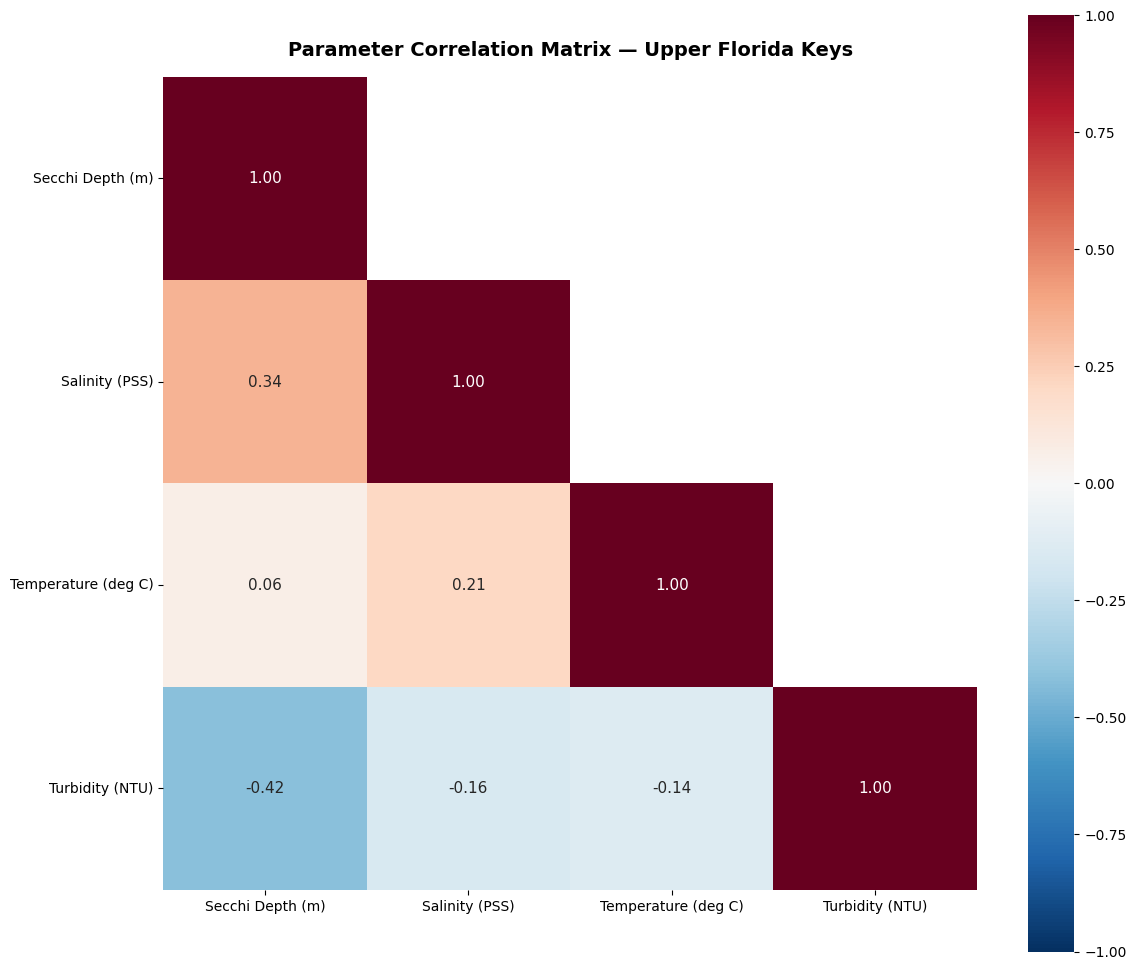

In [6]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = wq_gdf[param_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0,        # no gaps
            square=True,
            annot_kws={"size": 11})

ax.set_title("Parameter Correlation Matrix — Upper Florida Keys", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)  # horizontal x labels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

## Seasonal Box Plots

Boxplots for each parameter seperated by season with mean and outliers

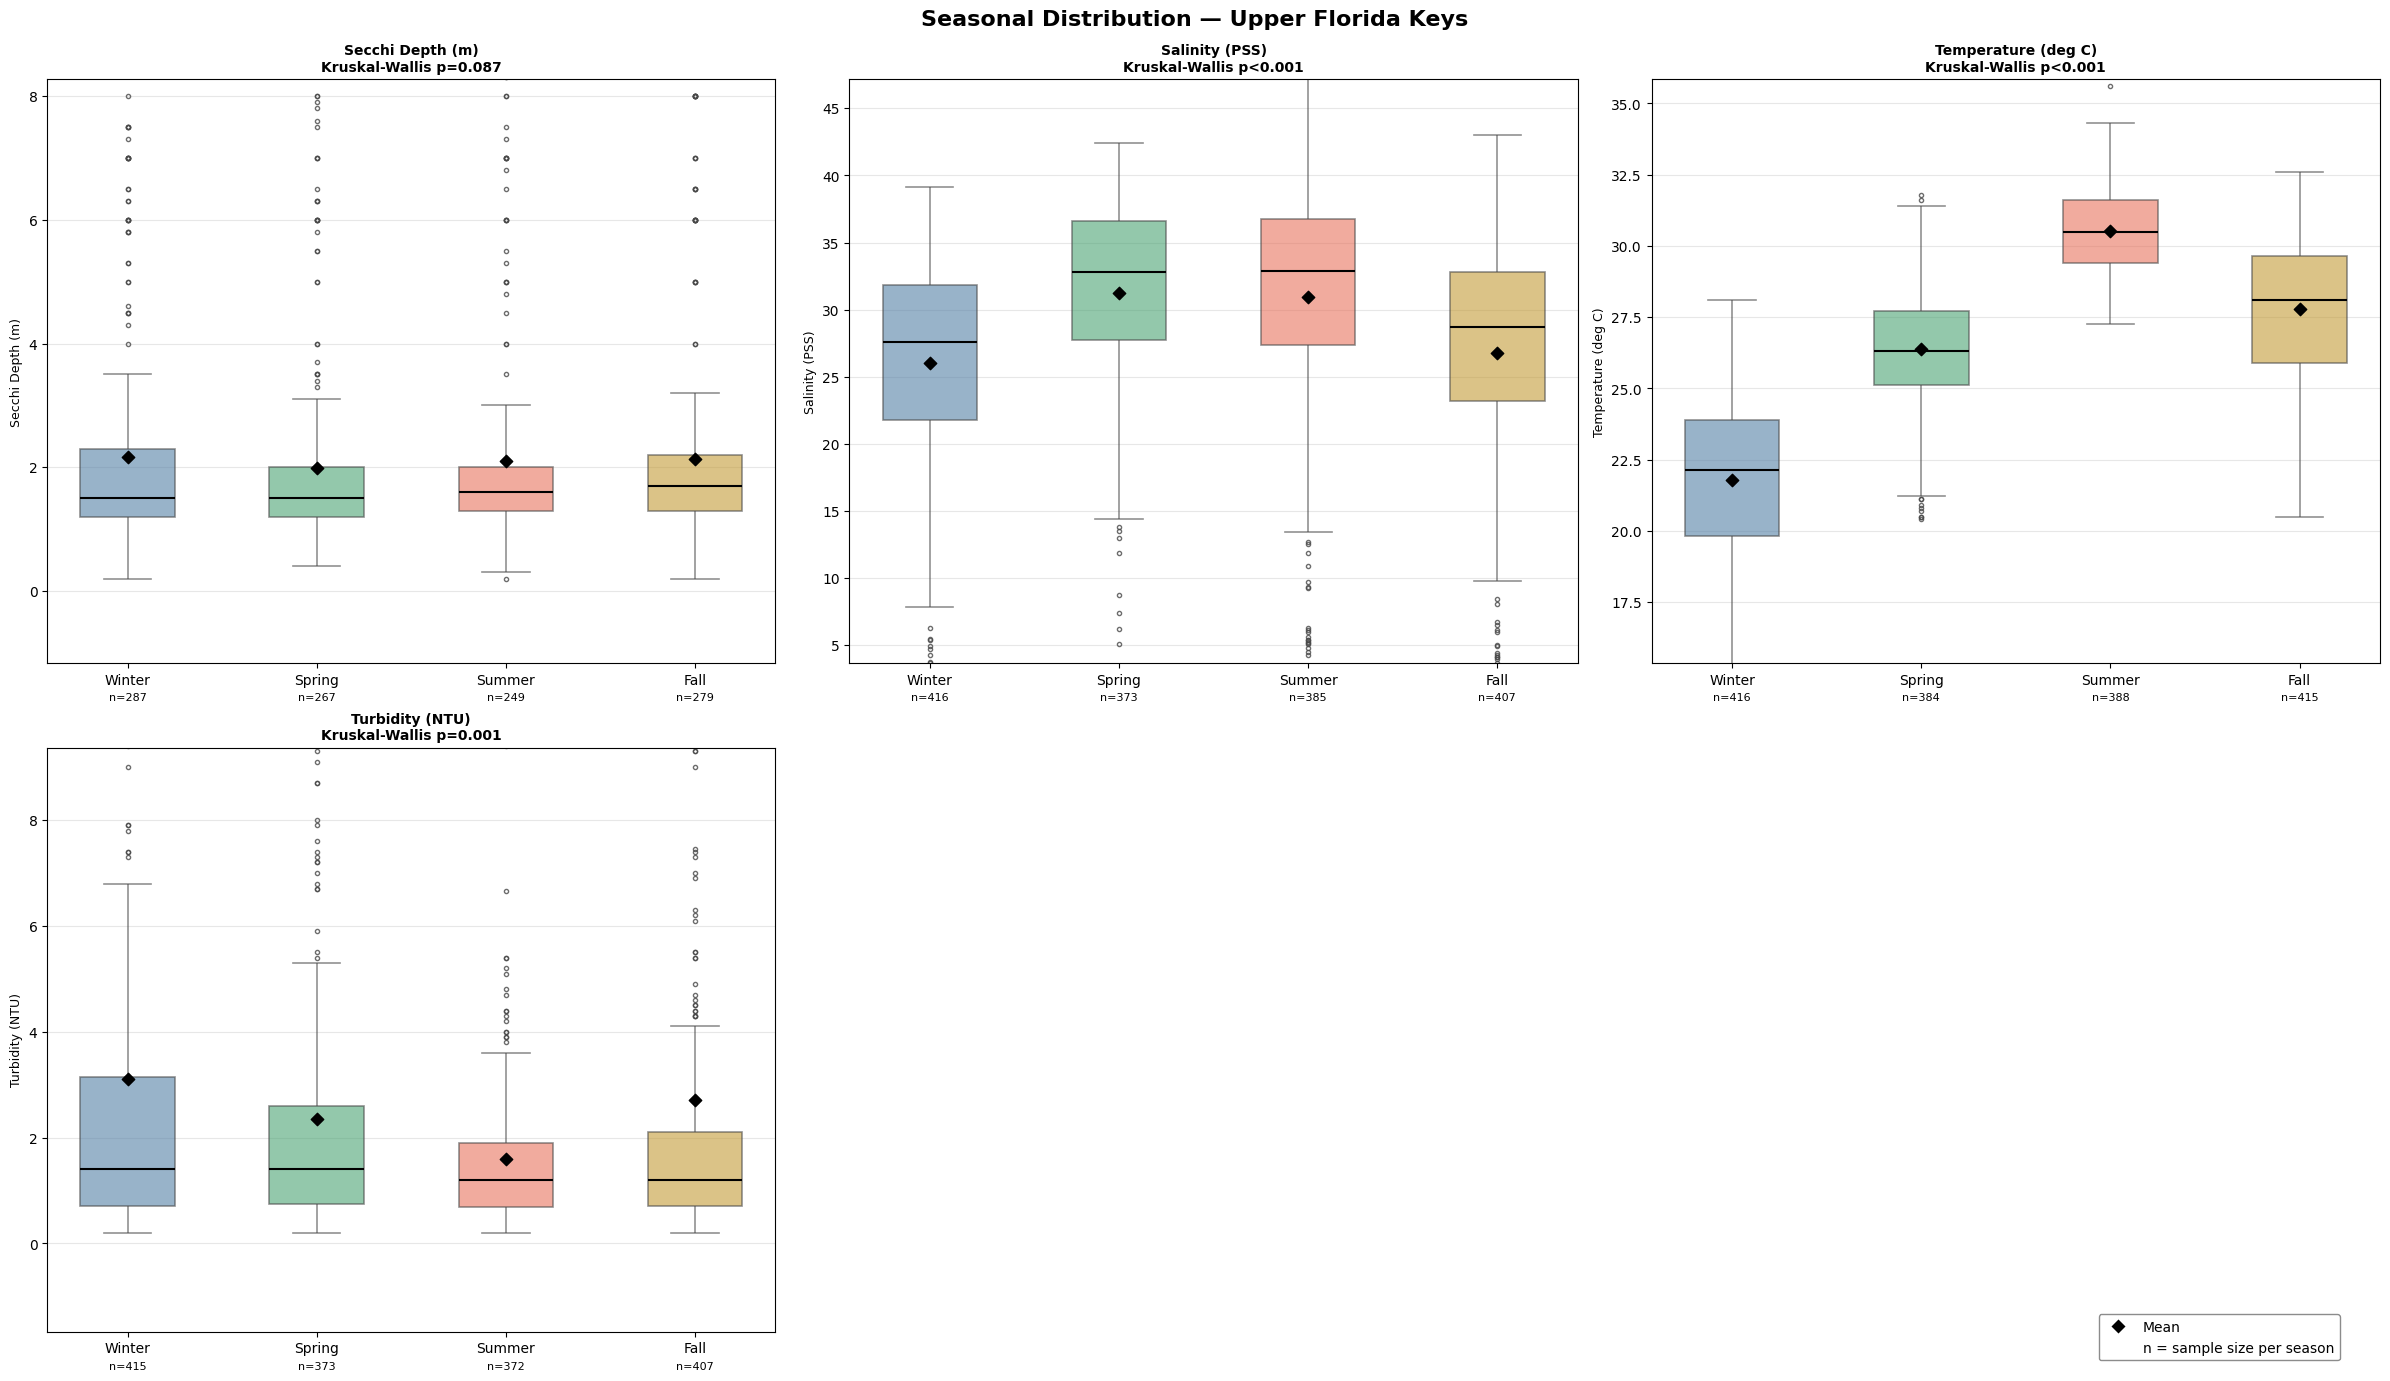

In [7]:
# Seasonal Boxplots (one per parameter)
wq_plot = wq_gdf.reset_index().copy()
wq_plot["Month"] = pd.to_datetime(wq_plot["Date"]).dt.month
wq_plot["Season"] = wq_plot["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
})

# Set Season Pallets
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_palette = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "tomato",
    "Fall":   "goldenrod"
}

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for i, col in enumerate(param_cols):
    ax = axes[i]

    # Boxplot
    sns.boxplot(data=wq_plot, x="Season", y=col, hue="Season",
                order=season_order, palette=season_palette,
                legend=False, ax=ax, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.8),
                boxprops=dict(alpha=0.6),
                whiskerprops=dict(alpha=0.6),
                capprops=dict(alpha=0.6),
                medianprops=dict(color='black', linewidth=1.5))
    
    # Auto zoom y axis with padding around the data range
    col_data = wq_plot[col].dropna()
    q1 = col_data.quantile(0.05)
    q3 = col_data.quantile(0.95)
    padding = (q3 - q1) * 0.3
    ax.set_ylim(q1 - padding, q3 + padding)

    # Add mean marker
    means = wq_plot.groupby("Season")[col].mean()
    for j, season in enumerate(season_order):
        if season in means:
            ax.scatter(j, means[season], marker='D', color='black',
                      s=40, zorder=5, label='Mean' if j == 0 else "")

    # Add sample size per season
    for j, season in enumerate(season_order):
        n = wq_plot[wq_plot["Season"] == season][col].dropna().shape[0]
        ax.text(j, -0.05, f'n={n}',
                ha='center', va='top', fontsize=8, color='black',
                transform=ax.get_xaxis_transform())

    # Add significance brackets between Winter and Summer
    groups = [wq_plot[wq_plot["Season"] == s][col].dropna() for s in season_order]
    _, p_val = stats.kruskal(*[g for g in groups if len(g) > 0])
    p_str = "p<0.001" if p_val < 0.001 else f"p={p_val:.3f}"
    ax.set_title(f"{col}\nKruskal-Wallis {p_str}", fontsize=10, fontweight="bold")

    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Seasonal Distribution — Upper Florida Keys", fontsize=16, fontweight="bold")

# Build shared legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
           markersize=8, label='Mean'),
    Line2D([0], [0], color='none', label='n = sample size per season')
]

fig.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=10,
           frameon=True, framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("seasonal_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## Spatial Visualization of Parameters

A visual display of the mean value for each parameter per station. Includes overlayed map of study area and exact shapefile. 

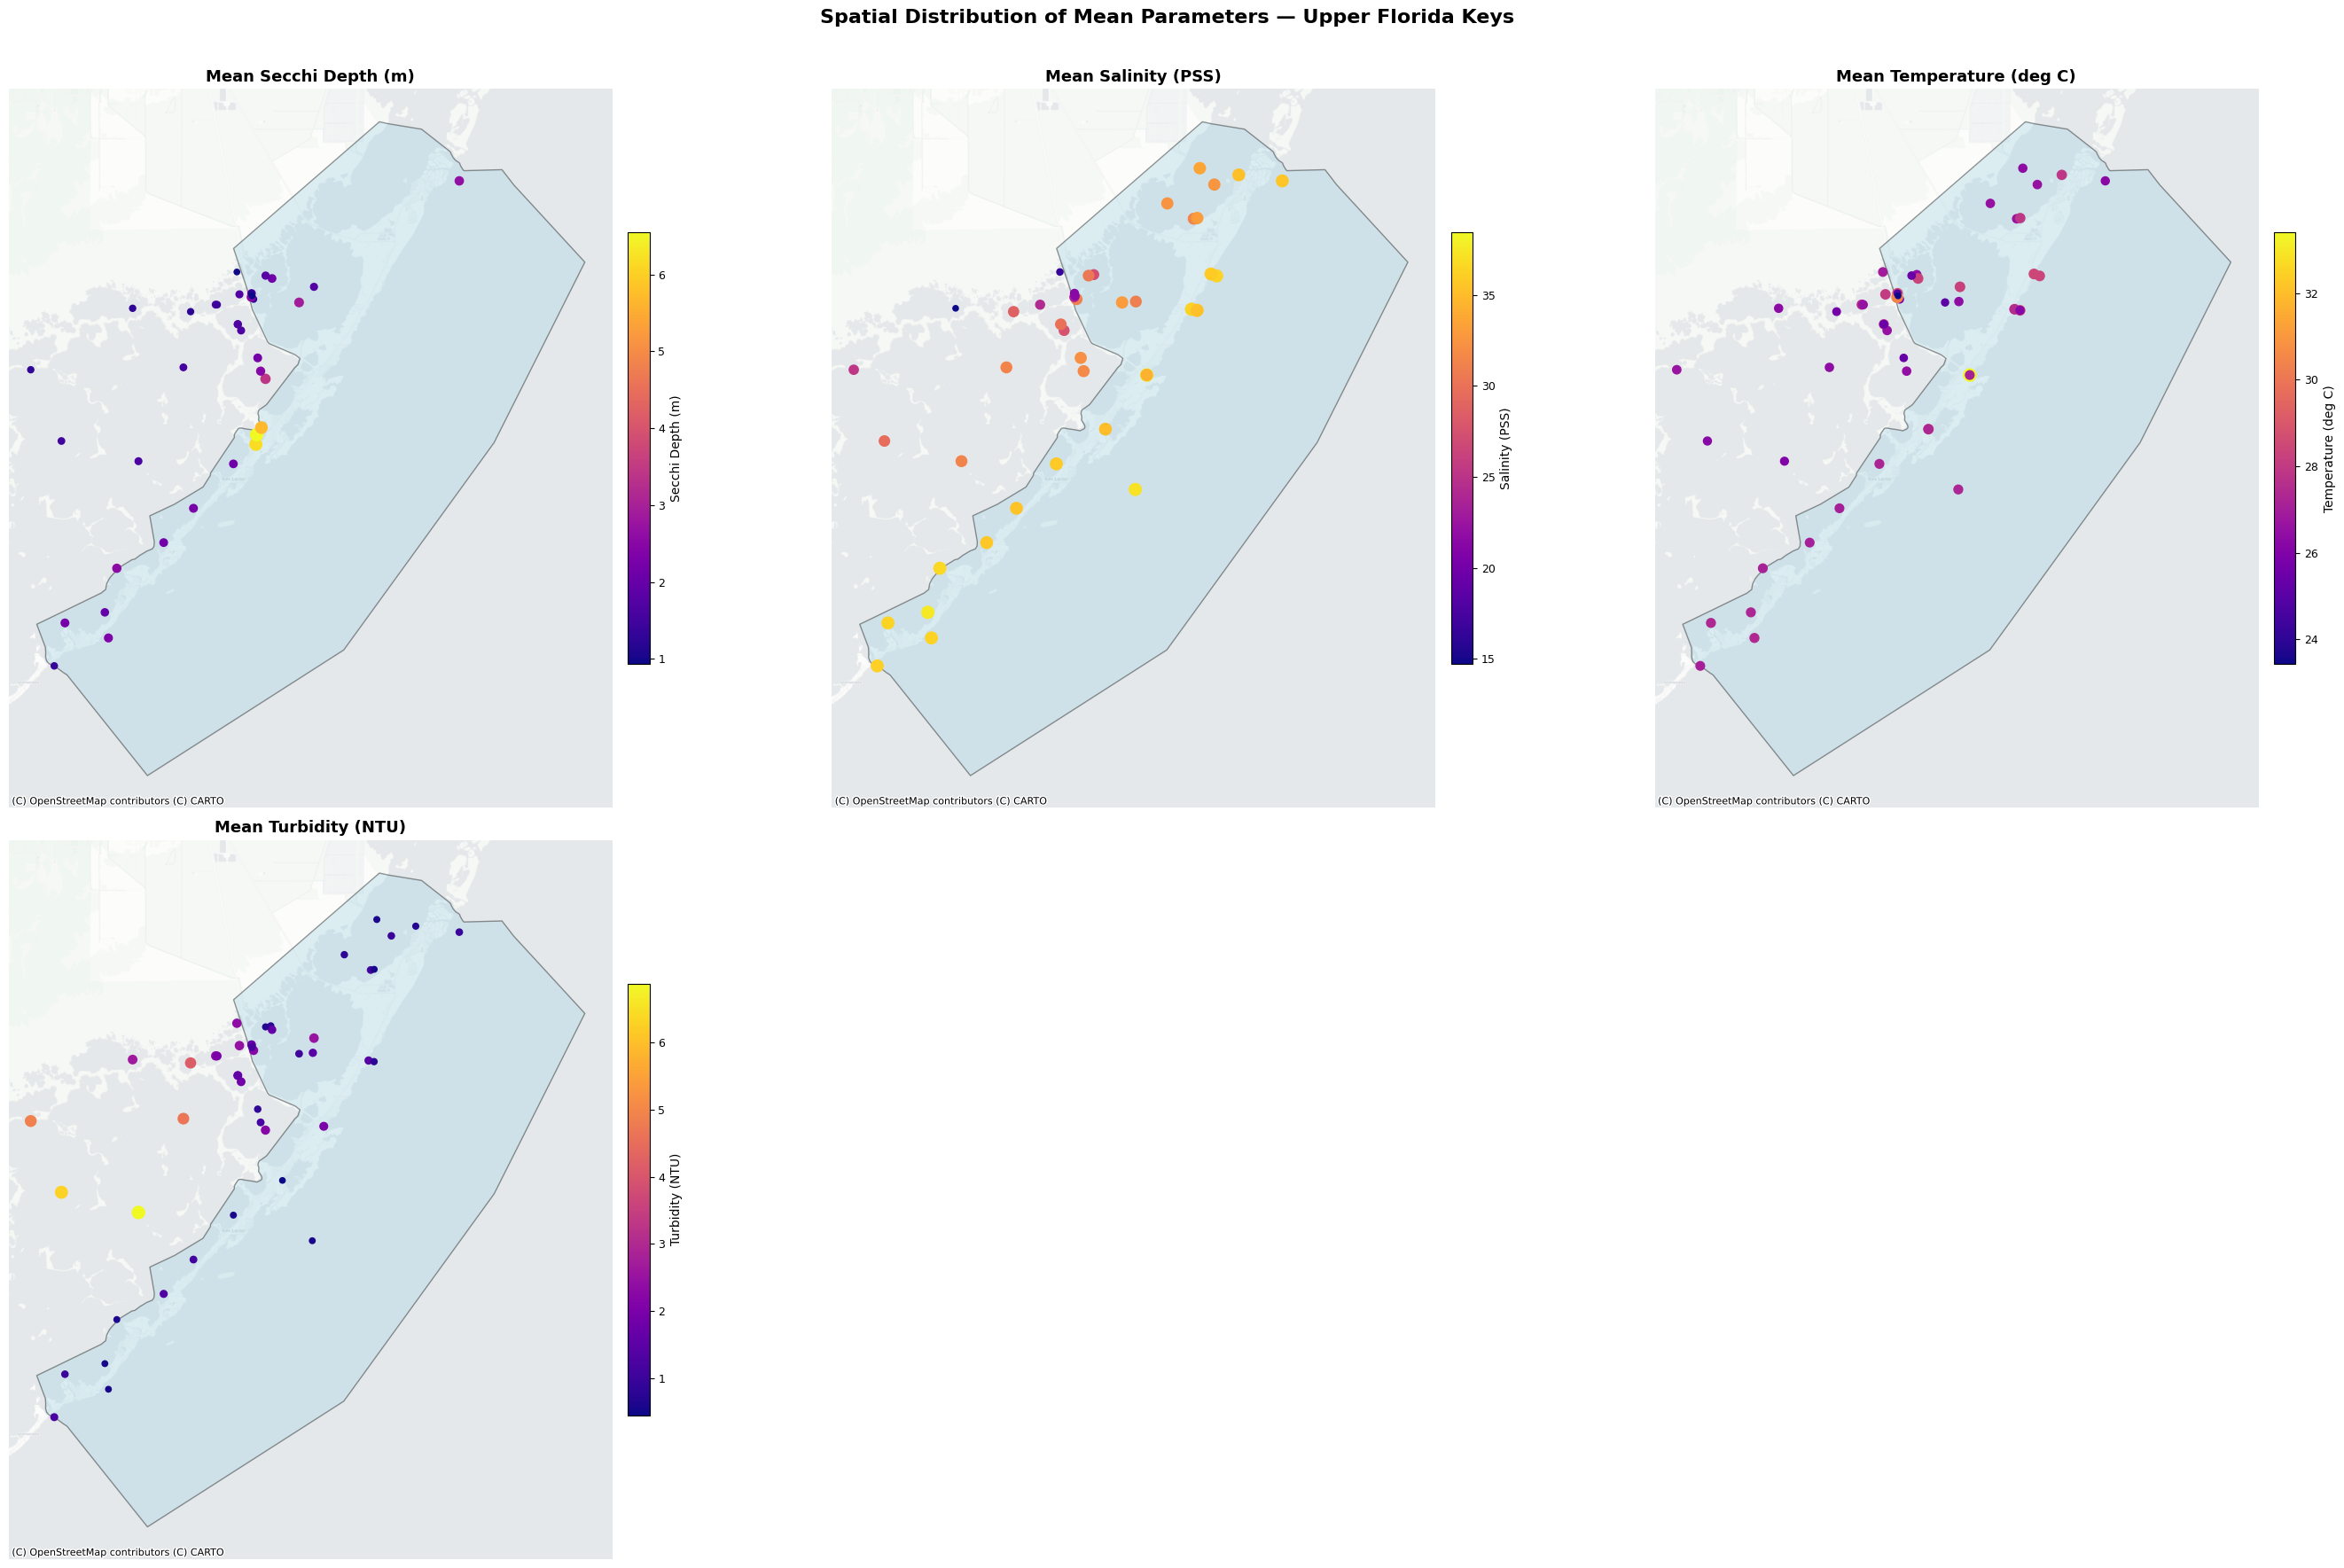

In [8]:
station_means = wq_gdf.groupby("MonitoringLocationIdentifier")[param_cols].mean()
wq_stations = wq_gdf.dissolve(by="MonitoringLocationIdentifier")[["geometry"]].join(station_means)

# Read reef shapefile
reef_shape = gpd.read_file("UpperKeys_FL.shp")

# Reproject to Web Mercator for basemap compatibility
reef_wm     = reef_shape.to_crs(epsg=3857)
stations_wm = wq_stations.to_crs(epsg=3857)

fig, axes = plt.subplots(2, 3, figsize=(28, 18))
axes = axes.flatten()

for i, col in enumerate(param_cols):
    ax = axes[i]

    # Plot shapefile FIRST to set axes extent
    reef_wm.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.4, zorder=1)

    # Add basemap using explicit CRS
    try:
        ctx.add_basemap(ax, crs=stations_wm.crs,
                        source=ctx.providers.CartoDB.Positron,
                        alpha=0.6, zorder=0, zoom=12)
    except Exception as e:
        print(f"Basemap error: {e}")
        pass

    # Scale marker size to value
    values = stations_wm[col].dropna()
    scaled_sizes = ((values - values.min()) / (values.max() - values.min()) * 80) + 20

    # Plot stations
    stations_wm.dropna(subset=[col]).plot(
        ax=ax, column=col, cmap="plasma",
        markersize=scaled_sizes,
        legend=False,
        zorder=3
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap="plasma",
                                norm=plt.Normalize(vmin=values.min(), vmax=values.max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label(col, fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_title(f"Mean {col}", fontsize=13, fontweight="bold")
    ax.axis("off")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Spatial Distribution of Mean Parameters — Upper Florida Keys",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("spatial_means.png", dpi=150, bbox_inches="tight")
plt.show()

## Relationship between parameters

Visualization of the relationship between parameters, organized seasonaly. 

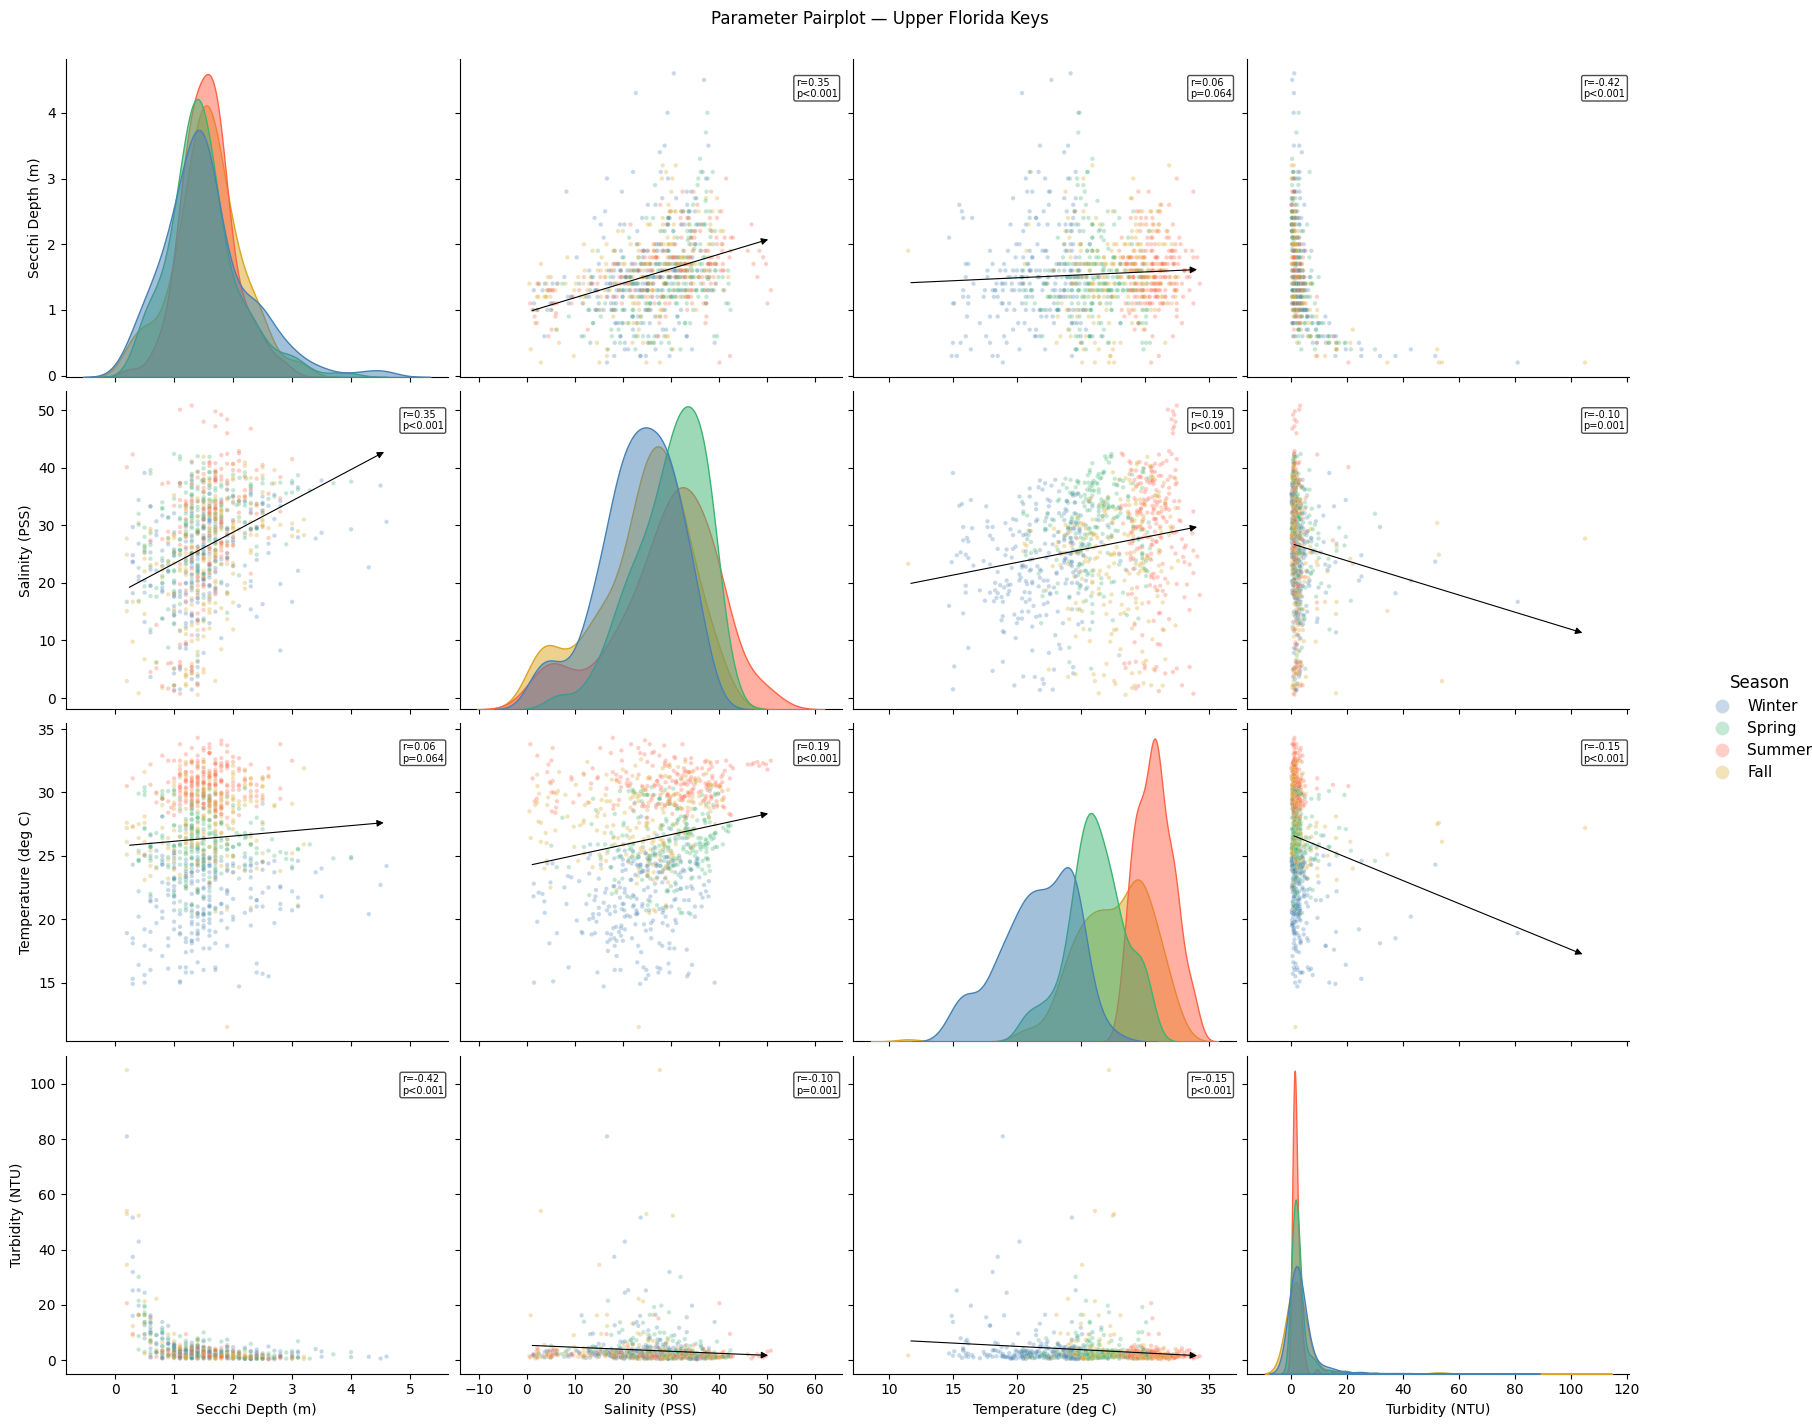

In [9]:
# Pairplot (relationships between all parameters)
pair_data = wq_gdf[param_cols].dropna().copy()
pair_data = wq_gdf[param_cols].dropna().copy()

# Add season for color coding
pair_data["Season"] = pair_data.index.month.map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

season_palette = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "tomato",
    "Fall":   "goldenrod"
}

# Pairplot colored by season
g = sns.pairplot(pair_data, hue="Season", palette=season_palette,
                 diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10},
                 diag_kws={"alpha": 0.5},
                 height=3.5, aspect=1.2)

# Add correlation coefficients and regression lines to off-diagonal plots
for i, row_col in enumerate(param_cols):
    for j, col_col in enumerate(param_cols):
        if i == j:
            continue
        ax = g.axes[i, j]

        # Get clean paired data for these two columns
        paired = pair_data[[row_col, col_col]].dropna()
        if len(paired) < 5:
            continue

        x = paired[col_col]
        y = paired[row_col]

        # Regression line with arrow
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_start = x.min()
        x_end   = x.max()
        y_start = slope * x_start + intercept
        y_end   = slope * x_end   + intercept

        ax.annotate("",
                    xy=(x_end, y_end),
                    xytext=(x_start, y_start),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color="black",
                        lw=0.8,
                    ))

        # Correlation coefficient and p-value
        p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
        ax.annotate(f"r={r:.2f}\n{p_str}",
                    xy=(0.88, 0.88), xycoords='axes fraction',
                    fontsize=7, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Move and resize legend
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_title("Season")
for text in g._legend.get_texts():
    text.set_fontsize(11)
g._legend.get_title().set_fontsize(12)
for handle in g._legend.legend_handles:
    handle.set_markersize(10)

g.fig.suptitle("Parameter Pairplot — Upper Florida Keys", y=1.02)
plt.savefig("pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Station Summary

In [22]:
station_summary = wq_gdf.groupby("MonitoringLocationIdentifier").apply(lambda x: pd.Series({
    'Sampling_Days': x.index.nunique(),
    'Dates': f"{min(x.index).date()} to {max(x.index).date()}"
})).reset_index().sort_values("Sampling_Days", ascending=False).reset_index(drop=True)

# Select only the top 15 most contributing stations for display 
top15 = station_summary.head(15).copy()

print(f"Total stations: {len(station_summary)}")
print(f"Top 15 stations account for "
      f"{top15['Sampling_Days'].sum() / station_summary['Sampling_Days'].sum():.0%} "
      f"of total sampling effort")
print(f"Inter-station distance — Min: 3.14 km | Mean: 15.52 km | Max: 37.16 km\n")

display(top15[['MonitoringLocationIdentifier', 'Sampling_Days', 'Dates']].style.hide(axis="index"))

Total stations: 56
Top 15 stations account for 77% of total sampling effort
Inter-station distance — Min: 3.14 km | Mean: 15.52 km | Max: 37.16 km



C:\Users\ianra\AppData\Local\Temp\ipykernel_8504\493099677.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_summary = wq_gdf.groupby("MonitoringLocationIdentifier").apply(lambda x: pd.Series({


MonitoringLocationIdentifier,Sampling_Days,Dates
21FLSFWM_WQX-6599,112,2015-02-03 to 2024-12-11
21FLSFWM_WQX-6616,112,2015-02-03 to 2024-12-11
21FLSFWM_WQX-6604,112,2015-02-03 to 2024-12-11
21FLSFWM_WQX-6601,112,2015-02-03 to 2024-12-11
21FLSFWM_WQX-6602,111,2015-02-03 to 2024-12-11
21FLDADE_WQX-BB47,110,2015-01-07 to 2024-12-04
21FLDADE_WQX-BB51,110,2015-01-07 to 2024-12-04
21FLDADE_WQX-BB50,110,2015-01-07 to 2024-12-04
21FLSFWM_WQX-6603,109,2015-02-03 to 2024-12-11
21FLDADE_WQX-BB48,76,2018-04-04 to 2024-12-04


## Summary

This notebook produces exploratory figures describing the spatial and 
temporal distribution of water quality parameters across the Upper 
Florida Keys estuary.

**Figures produced:**
- `correlation_heatmap.png` — Pearson correlation matrix across all parameters
- `seasonal_boxplots.png` — seasonal distribution with Kruskal-Wallis significance
- `time_series.png` — monthly mean time series with rolling mean and ±1 SD band
- `pairplot.png` — bivariate relationships colored by season
- `spatial_means.png` — spatial distribution of mean parameter values

**Key observations:**
- Turbidity and Secchi Depth are inversely related as expected
- Strong seasonal signal in Temperature and Salinity
- Spatial variability across monitoring stations visible in mean parameter maps
- 56 monitoring stations across the study area — top 15 stations account for 77% of total sampling effort (mean inter-station distance 15.5 km)

**Next:** `06_time_series_analysis` for trend analysis and spectral index integration.

## Resources and References 
- Elshall, A. (2026). Pandas, Matplotlib [Environmental Data Science course notebook(s)] FGCU.
- P. Villa, A. Mousivand, and M. Bresciani, “Aquatic vegetation indices assessment through radiative transfer modeling and linear mixture simulation,” International Journal of Applied Earth Observation and Geoinformation, vol. 30, pp. 113–127, 2014. https://doi.org/10.1016/j.jag.2014.01.017
- Code assistance provided by Claude (Anthropic, 2026). https://claude.ai/